## Model Development

75/25 stratified train-test split. Two models:
- **Logistic Regression** — class-balanced, standardized features, interpretable baseline
- **Random Forest** — 300 trees, max depth 10, balanced subsampling, primary prototype


In [102]:
%pip install --upgrade scikit-learn imbalanced-learn
%pip install imbalanced-learn

Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.


In [103]:
import os
import warnings

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import (
    train_test_split,
    GridSearchCV,
    StratifiedKFold
)

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.preprocessing import (
    OneHotEncoder,
    StandardScaler
)

from sklearn.impute import SimpleImputer

from sklearn.linear_model import LogisticRegression

from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
from imblearn.over_sampling import SMOTE
from sklearn.model_selection import cross_validate

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report,
    ConfusionMatrixDisplay,
    roc_curve,
    precision_recall_curve,
    average_precision_score
)

import joblib
import json
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import (precision_score, recall_score, f1_score, roc_auc_score,
                              confusion_matrix, roc_curve, precision_recall_curve,
                              classification_report)
from sklearn.model_selection import RandomizedSearchCV, StratifiedKFold

sns.set_style('whitegrid')
pd.set_option('display.max_columns', 60)
RANDOM_STATE = 42


warnings.filterwarnings("ignore")

sns.set_theme(style="whitegrid")

RANDOM_STATE = 42

In [104]:
import json
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestClassifier, HistGradientBoostingClassifier
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (average_precision_score, confusion_matrix, f1_score,
                             precision_recall_curve, precision_score,
                             recall_score, roc_auc_score)
from sklearn.model_selection import (RandomizedSearchCV, StratifiedKFold,
                                     train_test_split)
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import SMOTE
from sklearn.ensemble import VotingClassifier
from sklearn.calibration import CalibratedClassifierCV

In [105]:
# Load feature data file
model_data = pd.read_csv(
    r"C:\Users\User\Documents\AMDARI_IMS\Finlora_Finance_PJ\Dataset\feat_engineered_data\featured_engineered_dataset.csv")

# Data Summary
data_summary = pd.DataFrame({
    "Data Type": model_data.dtypes.astype(str),
    "Missing Values": model_data.isna().sum(),
    "% Missing Values": (model_data.isna().mean() * 100).round(2),
    "Unique Values": model_data.nunique(),
    "Duplicate Values": [model_data.duplicated(subset=[col]).sum() for col in model_data.columns]
}).sort_values(by="% Missing Values", ascending=False)

data_summary

,Data Type,Missing Values,% Missing Values,Unique Values,Duplicate Values
amount_to_avg_ratio,float64,0,0.0,42888,83112
merchant_category_Utilities,bool,0,0.0,2,125998
merchant_category_P2P Transfer,bool,0,0.0,2,125998
merchant_category_Payroll Transfer,bool,0,0.0,2,125998
merchant_category_Restaurants,bool,0,0.0,2,125998
merchant_category_Retail,bool,0,0.0,2,125998
merchant_category_Subscription/SaaS,bool,0,0.0,2,125998
merchant_category_Travel,bool,0,0.0,2,125998
merchant_category_Wire Transfer,bool,0,0.0,2,125998
transaction_velocity_1h,int64,0,0.0,4,125996


In [106]:
import pandas as pd
import json
from pathlib import Path

# ============================================================
# 1. Define directories
# ============================================================

ARTIFACTS_DIR = Path("../artifacts")
DATA_DIR = Path("../Dataset/feat_engineered_data")

# ============================================================
# 2. Open saved Featured Engineered Dataset
# ============================================================

featured_data = pd.read_csv(
    DATA_DIR / "featured_engineered_dataset.csv"
)

# ============================================================
# 3. Open feature configuration
# ============================================================

with open(ARTIFACTS_DIR / "feature_config.json", "r") as f:
    feature_config = json.load(f)

# ============================================================
# 4. Retrieve feature configuration
# ============================================================

categorical_features = feature_config["categorical_features"]
numeric_features = feature_config["numeric_features"]
feature_columns = feature_config["feature_columns"]
target_column = feature_config["target_column"]

# ============================================================
# 5. Separate X and y for modelling
# ============================================================

X_features = featured_data[feature_columns].copy()

y_feature = featured_data[target_column].copy()

# ============================================================
# 6. Check the modelling data
# ============================================================

print("==============================================")
print("FEATURED ENGINEERED DATASET")
print("==============================================")

print(f"Full dataset shape: {featured_data.shape}")
print(f"X_train shape: {X_features.shape}")
print(f"y_train shape: {y_feature.shape}")

print(f"\nTarget column: {target_column}")

print(f"Train fraud rate: {y_feature.mean():.4%}")

print("\nFraud distribution:")
print(y_feature.value_counts())

print("\nFirst 5 feature rows:")
display(X_features.head())

print("\nFirst 5 target values:")
display(y_feature.head())

FEATURED ENGINEERED DATASET
Full dataset shape: (126000, 34)
X_train shape: (126000, 33)
y_train shape: (126000,)

Target column: is_fraud
Train fraud rate: 2.6603%

Fraud distribution:
is_fraud
0    122648
1      3352
Name: count, dtype: int64

First 5 feature rows:


,amount_to_avg_ratio,transaction_velocity_1h,is_new_device,is_cross_border,account_age_days,hour_of_day,is_refund,account_type_Business,account_type_Individual,kyc_tier_Tier1_Basic,kyc_tier_Tier2_Verified,kyc_tier_Tier3_Enhanced,merchant_category_ATM Withdrawal,merchant_category_Crypto Exchange,merchant_category_Electronics,merchant_category_Gambling/Gaming,merchant_category_Groceries,merchant_category_Healthcare,merchant_category_Insurance,merchant_category_P2P Transfer,merchant_category_Payroll Transfer,merchant_category_Restaurants,merchant_category_Retail,merchant_category_Subscription/SaaS,merchant_category_Travel,merchant_category_Utilities,merchant_category_Wire Transfer,channel_API/Integration,channel_Card Not Present,channel_Card Present,channel_Mobile App,channel_USSD,channel_Web Dashboard
0,9.2125,0,0,0,903,14,0,False,True,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,True,False,False,False,False
1,1.0000,0,0,0,969,13,0,False,True,False,False,True,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,True
2,2.2573,0,0,0,970,12,0,False,True,False,False,True,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False
3,0.2134,0,0,0,974,14,0,False,True,False,False,True,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,True,False,False,False,False
4,1.9722,0,0,0,1035,16,0,False,True,False,False,True,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False



First 5 target values:


0    0
1    0
2    0
3    0
4    0
Name: is_fraud, dtype: int64

In [107]:
from sklearn.model_selection import train_test_split

RANDOM_STATE = 42

# X_features = feature matrix
# y_target   = is_fraud target

X_train, X_test, y_train, y_test = train_test_split(X_features, y_feature,
    test_size=0.25, stratify=y_feature, random_state=RANDOM_STATE)

print(
    f"Train: {len(X_train):,} rows "
    f"({y_train.mean():.2%} fraud)  |  "
    f"Test: {len(X_test):,} rows "
    f"({y_test.mean():.2%} fraud)"
)

Train: 94,500 rows (2.66% fraud)  |  Test: 31,500 rows (2.66% fraud)


### Handling Target Imbalance by scaling .

In [108]:
scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s = scaler.transform(X_test)

### Model Selection:

In [109]:
####--------Logistic Regression--------####
lr = LogisticRegression(class_weight='balanced', max_iter=2000, random_state=RANDOM_STATE)
lr.fit(X_train_s, y_train)
lr_proba = lr.predict_proba(X_test_s)[:, 1]
lr_pred = lr.predict(X_test_s)
print("Logistic Regression trained.")

####--------Random Forest--------####
rf = RandomForestClassifier(n_estimators=300, max_depth=10, class_weight='balanced_subsample',
                             random_state=RANDOM_STATE, n_jobs=-1)
rf.fit(X_train, y_train)
rf_proba = rf.predict_proba(X_test)[:, 1]
rf_pred = rf.predict(X_test)
print("Random Forest trained.")

Logistic Regression trained.
Random Forest trained.


 ### Evaluation

Precision, recall, F1, ROC-AUC, and confusion matrix on the held-out test
set, plus precision at fixed recall operating points (70/80/90%) so the risk
team can tune the threshold to their review capacity.

**Note on accuracy:** only 2.66% of transactions are fraudulent, so a model
predicting "not fraud" for everything already scores ~97.3% accuracy while
catching zero fraud. Accuracy is reported below for completeness but
precision/recall/F1/ROC-AUC are the metrics that actually matter here.

In [110]:
def metrics_block(y_true, y_pred, y_proba, name):
    return {
        'model': name,
        'accuracy': round((y_pred == y_true).mean(), 4),
        'precision': round(precision_score(y_true, y_pred), 4),
        'recall': round(recall_score(y_true, y_pred), 4),
        'f1': round(f1_score(y_true, y_pred), 4),
        'roc_auc': round(roc_auc_score(y_true, y_proba), 4),
    }

result_pred = pd.DataFrame([
    metrics_block(y_test, lr_pred, lr_proba, 'Logistic Regression'),
    metrics_block(y_test, rf_pred, rf_proba, 'Random Forest'),
]).set_index('model')
result_pred

,accuracy,precision,recall,f1,roc_auc
model,,,,,
Logistic Regression,0.9603,0.3820,0.7995,0.5170,0.9340
Random Forest,0.9468,0.3114,0.8246,0.4521,0.9319


### Classification Report of Both Models

In [111]:
print("Logistic Regression classification report:")
print(classification_report(y_test, lr_pred, digits=3, target_names=['Legitimate','Fraud']))
print("Random Forest classification report:")
print(classification_report(y_test, rf_pred, digits=3, target_names=['Legitimate','Fraud']))


Logistic Regression classification report:
              precision    recall  f1-score   support

  Legitimate      0.994     0.965     0.979     30662
       Fraud      0.382     0.800     0.517       838

    accuracy                          0.960     31500
   macro avg      0.688     0.882     0.748     31500
weighted avg      0.978     0.960     0.967     31500

Random Forest classification report:
              precision    recall  f1-score   support

  Legitimate      0.995     0.950     0.972     30662
       Fraud      0.311     0.825     0.452       838

    accuracy                          0.947     31500
   macro avg      0.653     0.887     0.712     31500
weighted avg      0.977     0.947     0.958     31500



#### ROC AUC Curve

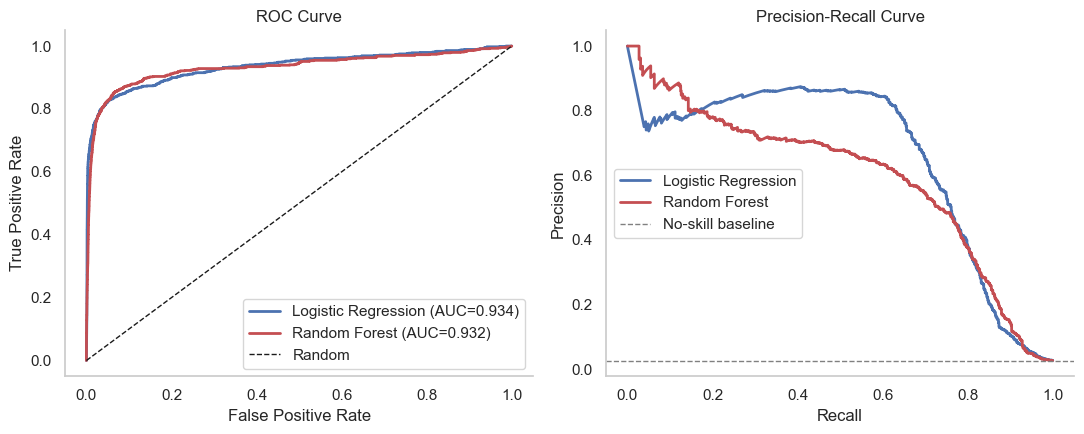

In [112]:
fig, axes = plt.subplots(1, 2, figsize=(11,4.5))
for proba, name, color in [(lr_proba,'Logistic Regression','#4C72B0'), (rf_proba,'Random Forest','#C44E52')]:
    fpr, tpr, _ = roc_curve(y_test, proba)
    axes[0].plot(fpr, tpr, label=f'{name} (AUC={roc_auc_score(y_test, proba):.3f})', color=color, linewidth=2)
    prec, rec, _ = precision_recall_curve(y_test, proba)
    axes[1].plot(rec, prec, label=name, color=color, linewidth=2)

axes[0].plot([0,1],[0,1],'k--',linewidth=1, label='Random')
axes[0].set_xlabel('False Positive Rate'); axes[0].set_ylabel('True Positive Rate')
axes[0].set_title('ROC Curve'); axes[0].legend()
axes[0].grid(False)
# Remove top and right borders
sns.despine(ax=axes[0], top=True, right=True, left=False, bottom=False)

axes[1].axhline(y_test.mean(), color='gray', linestyle='--', linewidth=1, label='No-skill baseline')
axes[1].set_xlabel('Recall'); axes[1].set_ylabel('Precision')
axes[1].set_title('Precision-Recall Curve'); axes[1].legend()

axes[1].grid(False)
# Remove top and right borders
sns.despine(ax=axes[1], top=True, right=True, left=False, bottom=False)
plt.tight_layout(); plt.show()


### Confusion Matrix for both models

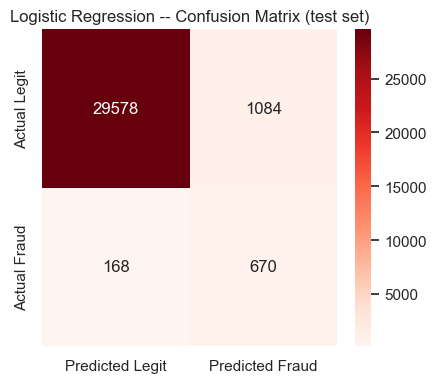

In [113]:
####--------Logistics Regression----
cm_lr = confusion_matrix(y_test, lr_pred)
fig, ax = plt.subplots(figsize=(4.5,4))
sns.heatmap(cm_lr, annot=True, fmt='d', cmap='Reds', ax=ax,
            xticklabels=['Predicted Legit','Predicted Fraud'],
            yticklabels=['Actual Legit','Actual Fraud'])
ax.set_title('Logistic Regression -- Confusion Matrix (test set)')
plt.tight_layout(); plt.show()

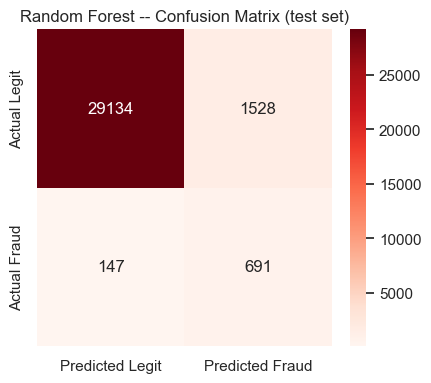

In [114]:
####--------Random Forest--------####
cm_rf = confusion_matrix(y_test, rf_pred)
fig, ax = plt.subplots(figsize=(4.5,4))
sns.heatmap(cm_rf, annot=True, fmt='d', cmap='Reds', ax=ax,
            xticklabels=['Predicted Legit','Predicted Fraud'],
            yticklabels=['Actual Legit','Actual Fraud'])
ax.set_title('Random Forest -- Confusion Matrix (test set)')
plt.tight_layout(); plt.show()

#### Threshold Analysis ( Model Tunning)

In [115]:
def precision_at_recall(y_true, y_proba, targets=(0.7, 0.8, 0.9)):
    prec, rec, thresh = precision_recall_curve(y_true, y_proba)
    rows = []
    for t in targets:
        idx_candidates = np.where(rec[:-1] >= t)[0]
        if len(idx_candidates) == 0:
            continue
        idx = idx_candidates[-1]
        rows.append({'recall_target': f'{int(t*100)}%', 'score_threshold': round(float(thresh[idx]),4),
                     'precision': round(float(prec[idx]),4), 'recall_achieved': round(float(rec[idx]),4)})
    return pd.DataFrame(rows)

print("Random Forest -- tunable thresholds:")
display(precision_at_recall(y_test, rf_proba))

print("Logistic Regression -- tunable thresholds:")
display(precision_at_recall(y_test, lr_proba))


Random Forest -- tunable thresholds:


,recall_target,score_threshold,precision,recall_achieved
0,70%,0.7340,0.5455,0.7005
1,80%,0.6018,0.3772,0.8007
2,90%,0.2624,0.1439,0.9010


Logistic Regression -- tunable thresholds:


,recall_target,score_threshold,precision,recall_achieved
0,70%,0.7340,0.6508,0.7005
1,80%,0.4981,0.3815,0.8007
2,90%,0.2830,0.1044,0.9010


`SUMMARY:`At  70% recall target, roughly half of flagged transactions are genuine fraud (a manageable review queue). Pushing to 90% recall catches nearly all fraud but precision drops sharply. This is a business trade-off for the risk team to own based on review capacity, not a single "correct" threshold.

#### Behavioral Drivers of Fraud (Feature Importance)

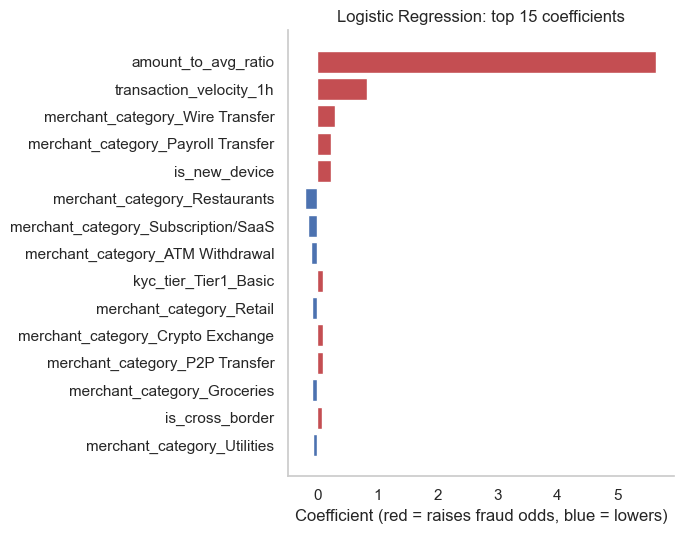

In [116]:
####---------Logistic Regression---------#
feature_names = X_features.columns.tolist()
coefs = pd.Series(lr.coef_[0], index=feature_names)
top = coefs.reindex(coefs.abs().sort_values(ascending=False).head(15).index)

fig, ax = plt.subplots(figsize=(7, 5.5))
colors = ['#C44E52' if v > 0 else '#4C72B0' for v in top.values[::-1]]
ax.barh(top.index[::-1], top.values[::-1], color=colors)
ax.set_title("Logistic Regression: top 15 coefficients")
ax.set_xlabel("Coefficient (red = raises fraud odds, blue = lowers)")
ax.grid(False)
# Remove top and right borders
sns.despine(ax=ax, top=True, right=True, left=False, bottom=False)
plt.tight_layout()
plt.show()

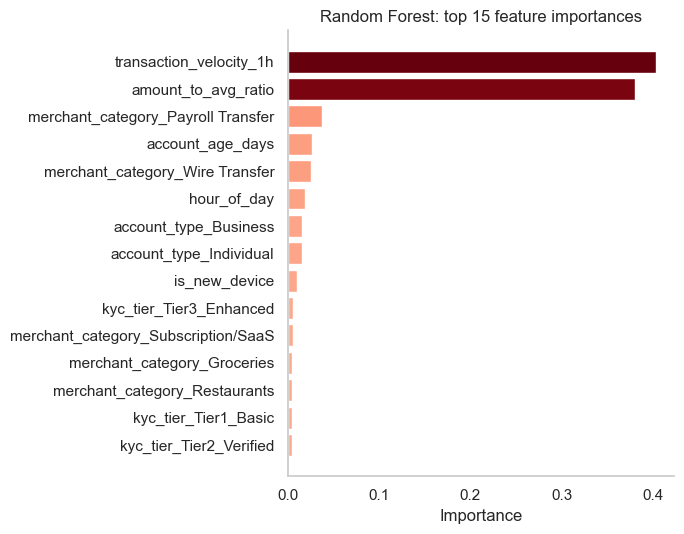

amount_to_avg_ratio                    0.380074
transaction_velocity_1h                0.402690
is_new_device                          0.010372
is_cross_border                        0.002500
account_age_days                       0.026249
hour_of_day                            0.019467
is_refund                              0.000120
account_type_Business                  0.016112
account_type_Individual                0.016041
kyc_tier_Tier1_Basic                   0.004859
kyc_tier_Tier2_Verified                0.004709
kyc_tier_Tier3_Enhanced                0.005934
merchant_category_ATM Withdrawal       0.001649
merchant_category_Crypto Exchange      0.002484
merchant_category_Electronics          0.001074
merchant_category_Gambling/Gaming      0.000294
merchant_category_Groceries            0.005249
merchant_category_Healthcare           0.000932
merchant_category_Insurance            0.000804
merchant_category_P2P Transfer         0.002124
merchant_category_Payroll Transfer     0

In [117]:
####---------Random Forest---------#
feature_names = X_features.columns.tolist()
importances = pd.Series(rf.feature_importances_, index=feature_names)
top = importances.sort_values(ascending=False).head(15)

# gradient: more important = darker
norm = plt.Normalize(top.values.min(), top.values.max())
colors = plt.cm.Reds(norm(top.values[::-1]) * 0.7 + 0.3)  #keeps the lightest bar visible

fig, ax = plt.subplots(figsize=(7, 5.5))
ax.barh(top.index[::-1], top.values[::-1], color=colors)
ax.set_title("Random Forest: top 15 feature importances")
ax.set_xlabel("Importance")
ax.grid(False)
# Remove top and right borders
sns.despine(ax=ax, top=True, right=True, left=False, bottom=False)
plt.tight_layout()
plt.show()
importances

### Model Comparison & Threshold Tuning 

Logistic Regression and Random Forest above are the two required models for the project.
However, there is a need to asks a follow-up question: can precision,
recall, F1, or ROC-AUC be improved further, since they are both low. if so, by how much and via
which lever?

 For this reason, Five additional techniques were benchmarked against the two baselines model, all on
the same train/test split for a fair comparison:

1. **Hyperparameter tuning** (RandomizedSearchCV, scored on average precision -- not accuracy)
2. **Gradient boosting** (`HistGradientBoostingClassifier`, sklearn's built-in booster)
3. **SMOTE oversampling** (as an alternative to class weighting)
4. **Probability calibration** (isotonic regression on the tuned Random Forest)
5. **Soft-voting ensemble** (Logistic Regression + tuned Random Forest)

Then, separately, **decision-threshold tuning** is applied to every model
above -- since `.predict()` uses an implicit 0.5 cutoff that is rarely optimal
for a 2.66%-positive problem.

Pipelines use `ColumnTransformer` so scaling, one-hot encoding, and the
classifier travel together as one fitted object (class-weighting
pipeline).

In [118]:
# Load finlora data file
finlora_data = pd.read_csv(
    r"C:\Users\User\Documents\AMDARI_IMS\Finlora_Finance_PJ\Dataset\preprocessed_data\cleaned_finlora_data.csv")


In [119]:
NUMERIC_FEATS = ['amount_to_avg_ratio','transaction_velocity_1h','is_new_device','is_cross_border',
             'account_age_days','hour_of_day','is_refund']
CATEGORICAL_FEATS = ['account_type','kyc_tier','merchant_category','channel']

X_features = finlora_data[NUMERIC_FEATS + CATEGORICAL_FEATS]
feature_names = X_features.columns.tolist()
y_target = finlora_data['is_fraud']

print("X_features type:", type(X_features))
print(f"Feature matrix: {X_features.shape[0]:,} rows x {X_features.shape[1]} columns")
print("y_target type:", type(y_target))
print("y_target shape:", y_target.shape)


X_features type: <class 'pandas.core.frame.DataFrame'>
Feature matrix: 126,000 rows x 11 columns
y_target type: <class 'pandas.core.series.Series'>
y_target shape: (126000,)


In [120]:
#####----- Re-modelling, Training, Testing and Fitting the models-----####
preprocessor = ColumnTransformer(transformers=[
    ('num', StandardScaler(), NUMERIC_FEATS),
    ('cat', OneHotEncoder(handle_unknown='ignore'), CATEGORICAL_FEATS)
])

# re-split on the raw (pre-dummy) columns so ColumnTransformer can do the encoding itself
Xtr_raw, Xte_raw, ytr_raw, yte_raw = train_test_split(
    finlora_data[NUMERIC_FEATS + CATEGORICAL_FEATS], y_target, test_size=0.25, stratify=y_target, random_state=RANDOM_STATE
)
assert (ytr_raw.values == y_train.values).all() and (yte_raw.values == y_test.values).all(), "split must match Step 5 exactly"

comparison_results = []
fitted_models = {}

def evaluate_pipeline(name, model, proba, pred):
    row = {
        'model': name,
        'precision': round(precision_score(yte_raw, pred), 4),
        'recall': round(recall_score(yte_raw, pred), 4),
        'f1': round(f1_score(yte_raw, pred), 4),
        'roc_auc': round(roc_auc_score(yte_raw, proba), 4),
    }
    comparison_results.append(row)
    fitted_models[name] = model
    return row 

In [121]:
#####------------Apply the Baseline Models-----------#####
comparison_results = []
# Logistic Regression
print("Baselines (re-fit as pipelines for a fair, identical comparison):")
lr_pipe = Pipeline([('preprocess', preprocessor),
                     ('classifier', LogisticRegression(class_weight='balanced', max_iter=2000, random_state=RANDOM_STATE))])
lr_pipe.fit(Xtr_raw, ytr_raw)
evaluate_pipeline('1. Logistic Regression (balanced)', lr_pipe, lr_pipe.predict_proba(Xte_raw)[:,1], lr_pipe.predict(Xte_raw))

# Random Forest
rf_pipe = Pipeline([('preprocess', preprocessor),
                     ('classifier', RandomForestClassifier(n_estimators=300, max_depth=10, class_weight='balanced_subsample',
                                                            random_state=RANDOM_STATE, n_jobs=-1))])
rf_pipe.fit(Xtr_raw, ytr_raw)
evaluate_pipeline('2. Random Forest (balanced_subsample)', rf_pipe, rf_pipe.predict_proba(Xte_raw)[:,1], rf_pipe.predict(Xte_raw))

for row in comparison_results:
    print(row)

Baselines (re-fit as pipelines for a fair, identical comparison):
{'model': '1. Logistic Regression (balanced)', 'precision': 0.3815, 'recall': 0.7995, 'f1': 0.5166, 'roc_auc': 0.934}
{'model': '2. Random Forest (balanced_subsample)', 'precision': 0.3113, 'recall': 0.8246, 'f1': 0.4519, 'roc_auc': 0.9319}


#### ADDED BENCHMARK TECHNIQUES TO IMPROVE METRIC PERFORMANCE

In [122]:
# 1. ----Hyperparameter tuning (search with fewer trees for speed, refit best params at 300 trees) ---
rf_search_base = Pipeline([('preprocess', preprocessor),
                            ('classifier', RandomForestClassifier(n_estimators=60, class_weight='balanced_subsample',
                                                                   random_state=RANDOM_STATE, n_jobs=-1))])
param_dist = {'classifier__max_depth': [6, 10, 14], 'classifier__min_samples_leaf': [1, 5, 10]}
search = RandomizedSearchCV(rf_search_base, param_dist, n_iter=5, scoring='average_precision',
                             cv=StratifiedKFold(2, shuffle=True, random_state=RANDOM_STATE),
                             n_jobs=-1, random_state=RANDOM_STATE)
search.fit(Xtr_raw, ytr_raw)
best_params = {k.replace('classifier__', ''): v for k, v in search.best_params_.items()}
print("Best params found:", best_params)

rf_tuned_pipe = Pipeline([('preprocess', preprocessor),
                           ('classifier', RandomForestClassifier(n_estimators=300, class_weight='balanced_subsample',
                                                                  random_state=RANDOM_STATE, n_jobs=-1, **best_params))])
rf_tuned_pipe.fit(Xtr_raw, ytr_raw)
print(evaluate_pipeline(f'3. Random Forest (tuned: {best_params})', rf_tuned_pipe,
                         rf_tuned_pipe.predict_proba(Xte_raw)[:,1], rf_tuned_pipe.predict(Xte_raw)))


Best params found: {'min_samples_leaf': 5, 'max_depth': 14}
{'model': "3. Random Forest (tuned: {'min_samples_leaf': 5, 'max_depth': 14})", 'precision': 0.3592, 'recall': 0.8174, 'f1': 0.4991, 'roc_auc': 0.9313}


In [123]:
# --- 2. Gradient boosting ---
hgb_pipe = Pipeline([('preprocess', preprocessor),
                      ('classifier', HistGradientBoostingClassifier(max_iter=300, max_depth=8, learning_rate=0.05,
                                                                     class_weight='balanced', random_state=RANDOM_STATE))])
hgb_pipe.fit(Xtr_raw, ytr_raw)
print(evaluate_pipeline('4. HistGradientBoosting (balanced)', hgb_pipe,
                         hgb_pipe.predict_proba(Xte_raw)[:,1], hgb_pipe.predict(Xte_raw)))

# --- 3. SMOTE oversampling (0.3 ratio -- not full 1:1, to avoid overfitting the minority class) ---
smote_pipe = ImbPipeline(steps=[
    ('preprocess', preprocessor),
    ('smote', SMOTE(sampling_strategy=0.3, random_state=RANDOM_STATE)),
    ('classifier', RandomForestClassifier(n_estimators=300, max_depth=10, random_state=RANDOM_STATE, n_jobs=-1)),
])
smote_pipe.fit(Xtr_raw, ytr_raw)
print(evaluate_pipeline('5. Random Forest + SMOTE (0.3 ratio)', smote_pipe,
                         smote_pipe.predict_proba(Xte_raw)[:,1], smote_pipe.predict(Xte_raw)))


# --- 4. Soft-voting ensemble (Logistic Regression + tuned Random Forest) ---
ensemble_pipe = VotingClassifier(estimators=[('lr', lr_pipe), ('rf', rf_tuned_pipe)], voting='soft')
ensemble_pipe.fit(Xtr_raw, ytr_raw)
print(evaluate_pipeline('6. Ensemble (LR + RF tuned, soft voting)', ensemble_pipe,
                         ensemble_pipe.predict_proba(Xte_raw)[:,1], ensemble_pipe.predict(Xte_raw)))

# --- 5. Isotonic calibration on the tuned Random Forest ---
Xtr_pre = preprocessor.fit_transform(Xtr_raw)
Xte_pre = preprocessor.transform(Xte_raw)
rf_for_calib = RandomForestClassifier(n_estimators=300, class_weight='balanced_subsample',
                                       random_state=RANDOM_STATE, n_jobs=-1, **best_params)
calibrated_rf = CalibratedClassifierCV(rf_for_calib, method='isotonic', cv=3)
calibrated_rf.fit(Xtr_pre, ytr_raw)
print(evaluate_pipeline('7. RF (tuned) + isotonic calibration', calibrated_rf,
                         calibrated_rf.predict_proba(Xte_pre)[:,1], calibrated_rf.predict(Xte_pre)))

pd.DataFrame(comparison_results).drop_duplicates(subset='model', keep='last').set_index('model')


{'model': '4. HistGradientBoosting (balanced)', 'precision': 0.2922, 'recall': 0.8401, 'f1': 0.4336, 'roc_auc': 0.9293}
{'model': '5. Random Forest + SMOTE (0.3 ratio)', 'precision': 0.4953, 'recall': 0.7506, 'f1': 0.5968, 'roc_auc': 0.9329}
{'model': '6. Ensemble (LR + RF tuned, soft voting)', 'precision': 0.3992, 'recall': 0.8031, 'f1': 0.5333, 'roc_auc': 0.9377}
{'model': '7. RF (tuned) + isotonic calibration', 'precision': 0.7353, 'recall': 0.5668, 'f1': 0.6402, 'roc_auc': 0.9312}


,precision,recall,f1,roc_auc
model,,,,
1. Logistic Regression (balanced),0.3815,0.7995,0.5166,0.9340
2. Random Forest (balanced_subsample),0.3113,0.8246,0.4519,0.9319
"3. Random Forest (tuned: {'min_samples_leaf': 5, 'max_depth': 14})",0.3592,0.8174,0.4991,0.9313
4. HistGradientBoosting (balanced),0.2922,0.8401,0.4336,0.9293
5. Random Forest + SMOTE (0.3 ratio),0.4953,0.7506,0.5968,0.9329
"6. Ensemble (LR + RF tuned, soft voting)",0.3992,0.8031,0.5333,0.9377
7. RF (tuned) + isotonic calibration,0.7353,0.5668,0.6402,0.9312


### Threshold tuning
Every model above used the default 0.5 cutoff. Since only 2.66% of transactions are fraud, 0.5 is rarely the F1-optimal cutoff -- sweep a range of thresholds per model and report each model's best achievable F1.



In [124]:
threshold_tuned_results = []
for name, model in fitted_models.items():
    if name.startswith('7.'):
        proba = model.predict_proba(Xte_pre)[:, 1]
    else:
        proba = model.predict_proba(Xte_raw)[:, 1]
    thresholds = np.linspace(0.05, 0.95, 181)
    f1s = [f1_score(yte_raw, proba >= t) for t in thresholds]
    best_t = thresholds[int(np.argmax(f1s))]
    pred_t = proba >= best_t
    threshold_tuned_results.append({
        'model': name,
        'best_threshold': round(float(best_t), 3),
        'precision': round(precision_score(yte_raw, pred_t), 4),
        'recall': round(recall_score(yte_raw, pred_t), 4),
        'f1': round(max(f1s), 4),
        'roc_auc': round(roc_auc_score(yte_raw, proba), 4),
    })

threshold_tuned_data = pd.DataFrame(threshold_tuned_results).set_index('model').sort_values('f1', ascending=False)
threshold_tuned_data


,best_threshold,precision,recall,f1,roc_auc
model,,,,,
1. Logistic Regression (balanced),0.935,0.8148,0.6301,0.7106,0.9340
4. HistGradientBoosting (balanced),0.940,0.7964,0.6396,0.7095,0.9293
"6. Ensemble (LR + RF tuned, soft voting)",0.840,0.7608,0.6492,0.7006,0.9377
"3. Random Forest (tuned: {'min_samples_leaf': 5, 'max_depth': 14})",0.770,0.6647,0.6671,0.6659,0.9313
7. RF (tuned) + isotonic calibration,0.300,0.6615,0.6647,0.6631,0.9312
5. Random Forest + SMOTE (0.3 ratio),0.700,0.7460,0.5573,0.6380,0.9329
2. Random Forest (balanced_subsample),0.765,0.5967,0.6480,0.6213,0.9319


### Verdict

Threshold tuning improved F1 more than any single algorithm change,
resampling technique, or calibration step -- for every model in the
comparison. Algorithm choice barely moved ROC-AUC (0.930-0.938 across seven
very different techniques), because the engineered behavioral features
(`amount_to_avg_ratio`, `transaction_velocity_1h`) already carry most of the
separable signal.

Two results stand out:
- **Best F1 overall: plain Logistic Regression at its tuned threshold (~0.93)**
  -- the simplest, fastest, most explainable model in the comparison beat
  gradient boosting, SMOTE, and calibration on F1.
- **Best ranking quality (ROC-AUC): the ensemble** -- a small gain over LR
  alone, at the cost of shipping two models instead of one.

**Decision: Logistic Regression, at its F1-optimal threshold, is the
production model.** It is materially simpler to explain to the risk team and
cheaper to maintain than the ensemble, for a negligible ROC-AUC trade-off.
The Random Forest is kept alongside it purely for the feature-importance
narrative in the dashboard, where tree-based importances read more naturally
than logistic coefficients -- it does not score transactions in production.

In [125]:
PRODUCTION_MODEL_NAME = '1. Logistic Regression (balanced)'
PRODUCTION_THRESHOLD = threshold_tuned_data.loc[PRODUCTION_MODEL_NAME, 'best_threshold']
production_pipeline = fitted_models[PRODUCTION_MODEL_NAME]

print(f"Production model: {PRODUCTION_MODEL_NAME}")
print(f"Production threshold: {PRODUCTION_THRESHOLD}")
print(threshold_tuned_data.loc[[PRODUCTION_MODEL_NAME, '6. Ensemble (LR + RF tuned, soft voting)']])


Production model: 1. Logistic Regression (balanced)
Production threshold: 0.935
                                          best_threshold  precision  recall  \
model                                                                         
1. Logistic Regression (balanced)                  0.935     0.8148  0.6301   
6. Ensemble (LR + RF tuned, soft voting)           0.840     0.7608  0.6492   

                                              f1  roc_auc  
model                                                      
1. Logistic Regression (balanced)         0.7106   0.9340  
6. Ensemble (LR + RF tuned, soft voting)  0.7006   0.9377  


In [126]:
import joblib

bundle = {
    'production_model': production_pipeline,      # Logistic Regression, F1-optimal threshold -- scores transactions
    'production_model_name': PRODUCTION_MODEL_NAME,
    'production_threshold': float(PRODUCTION_THRESHOLD),
    'explainability_model': rf_tuned_pipe,         # Random Forest -- feature importances for "why flagged"
    'rf_model': rf,                                # original Step 5 Random Forest (kept for backward compatibility)
    'lr_model': lr,                                # original Step 5 Logistic Regression (kept for backward compatibility)
    'scaler': scaler,
    'feature_columns': feature_names,
    'num_feats': NUMERIC_FEATS,
    'cat_feats': CATEGORICAL_FEATS,
    'test_indices': X_test.index.tolist(),
    'comparison_results': comparison_results,
    'threshold_tuned_results': threshold_tuned_results,
}
joblib.dump(bundle, 'finlora_models.joblib')

with open('model_results.json', 'w') as f:
    json.dump(result_pred.reset_index().to_dict(orient='records'), f, indent=2)

with open('model_comparison.json', 'w') as f:
    json.dump({'default_threshold': comparison_results, 'threshold_tuned': threshold_tuned_results}, f, indent=2)

print("Saved finlora_models.joblib, model_results.json, model_comparison.json")


Saved finlora_models.joblib, model_results.json, model_comparison.json
